#Problem 1 - Approximate Nearest Neighbors (25 points)

Given a dataset of vectors in a high-dimensional space, implement and analyze an Approximate Nearest Neighbors (ANN) solution using the Hierarchical Navigable Small World (HNSW) approach.

**Note #1**: Use the following test parameters:
- Number of vectors: 100
- Dimension: 2
- M-nearest neighbors: 2
- Test with query vector [0.5, 0.5]

**Required Libraries**: numpy, networkx, matplotlib

**Note #2**: Submit your code with clear documentation and visualizations of the graph structure and search process.


### (10 points) Task (a):

Implement a function `construct_HNSW(vectors, m_neighbors)` that builds a hierarchical
graph structure where:

- `vectors` is a numpy array of shape (n_vectors, dimension)
- `m_neighbors` is the number of nearest neighbors to connect in each layer
- Return a list of networkx graphs representing each layer

In [ ]:
#Import required libraries

#Define number of vectors, dimension, m-nearest-neighbors and generate a random dataset (specs mentioned above and in the PDF)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#### HNSW Construction

In [ ]:
#Define the function construct_HNSW

#Implement the function with the dataset
#YOUR CODE HERE


def construct_HNSW(vectors, m_neighbors, max_layer=3):
    """
    Construct Hierarchical Navigable Small World graph structure.

    Args:
        vectors: numpy array of shape (n_vectors, dimension)
        m_neighbors: number of nearest neighbors to connect at each layer
        max_layer: maximum number of layers (default 3)

    Returns:
        List of networkx.Graph objects, one for each layer
    """
    n_vectors = len(vectors)

    # Helper function: calculate Euclidean distance
    def euclidean_distance(v1, v2):
        return np.linalg.norm(v1 - v2)

    # Helper function: select layer using exponential probability
    def select_layer(ml=max_layer, mL=1/np.log(2)):
        layer = int(-np.log(np.random.uniform(0, 1)) * mL)
        return min(layer, ml)

    # Helper function: find k nearest neighbors
    def find_k_nearest_neighbors(node_idx, k, nodes_in_layer):
        candidates = [n for n in nodes_in_layer if n != node_idx]
        if len(candidates) == 0:
            return []

        distances = [(cand, euclidean_distance(vectors[node_idx], vectors[cand]))
                     for cand in candidates]
        distances.sort(key=lambda x: x[1])
        return [idx for idx, _ in distances[:k]]

    # Step 1: Assign each node to layers
    node_layers = [select_layer() for i in range(n_vectors)]

    # Step 2: Create graphs for each layer
    graphs = []

    for layer in range(max_layer + 1):
        G = nx.Graph()

        # Add nodes that belong to this layer or higher
        nodes_in_layer = [i for i in range(n_vectors) if node_layers[i] >= layer]

        for node_idx in nodes_in_layer:
            G.add_node(node_idx, pos=vectors[node_idx])

        # Step 3: Connect each node to its M nearest neighbors
        for node_idx in nodes_in_layer:
            neighbors = find_k_nearest_neighbors(node_idx, m_neighbors, nodes_in_layer)

            for neighbor in neighbors:
                if not G.has_edge(node_idx, neighbor):
                    distance = euclidean_distance(vectors[node_idx], vectors[neighbor])
                    G.add_edge(node_idx, neighbor, weight=distance)

        graphs.append(G)

    return graphs


# Test implementation
np.random.seed(42)
n_vectors = 100
dimension = 2
m_neighbors = 2

vectors = np.random.rand(n_vectors, dimension)

GraphArray = construct_HNSW(vectors, m_neighbors)

print(f"Created {len(GraphArray)} layers")
for i, G in enumerate(GraphArray):
    print(f"Layer {i}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")




Created 4 layers
Layer 0: 100 nodes, 129 edges
Layer 1: 42 nodes, 58 edges
Layer 2: 24 nodes, 29 edges
Layer 3: 13 nodes, 15 edges


### (8 points) Task (b):

Implement a function `search_HNSW(graph_layers, query)` that performs approximate nearest neighbor search. Your function should:

- Accept the graph layers from `construct HNSW` and a query vector
- Return the nearest neighbor found and the search path taken
- Use the layer-wise search strategy discussed in class

In [ ]:
#Your code here of the implementation

import numpy as np

def search_HNSW(graph_layers, query):
    """
    Perform approximate nearest neighbor search using HNSW.

    Args:
        graph_layers: List of networkx.Graph objects from construct_HNSW
        query: numpy array representing the query vector

    Returns:
        nearest_neighbor: Index of the nearest neighbor found
        search_path: List of (layer, node) tuples showing the search path
    """

    def euclidean_distance(v1, v2):
        return np.linalg.norm(v1 - v2)

    def greedy_search_layer(graph, entry_point, query):
        """
        Greedy search in a single layer.
        Returns the nearest node and the path taken.
        """
        current = entry_point
        path = [current]

        # Get position of current node
        current_pos = graph.nodes[current]['pos']
        current_dist = euclidean_distance(current_pos, query)

        changed = True
        while changed:
            changed = False

            # Check all neighbors of current node
            for neighbor in graph.neighbors(current):
                neighbor_pos = graph.nodes[neighbor]['pos']
                neighbor_dist = euclidean_distance(neighbor_pos, query)

                # Move to neighbor if it's closer
                if neighbor_dist < current_dist:
                    current = neighbor
                    current_dist = neighbor_dist
                    path.append(current)
                    changed = True
                    break

        return current, path

    # Initialize search path tracking
    search_path = []

    # Start from the top layer
    top_layer = len(graph_layers) - 1

    # Select entry point from top layer (random node)
    if graph_layers[top_layer].number_of_nodes() == 0:
        return None, []

    entry_point = list(graph_layers[top_layer].nodes())[0]

    # Search from top layer down to layer 0
    for layer in range(top_layer, -1, -1):
        G = graph_layers[layer]

        # Perform greedy search at this layer
        entry_point, layer_path = greedy_search_layer(G, entry_point, query)

        # Record search path with layer information
        for node in layer_path:
            search_path.append((layer, node))

    nearest_neighbor = entry_point

    return nearest_neighbor, search_path


# Test the search function
np.random.seed(42)
n_vectors = 100
dimension = 2
m_neighbors = 2
query_vector = np.array([0.5, 0.5])

# Assuming GraphArray already exists from construct_HNSW
vectors = np.random.rand(n_vectors, dimension)
GraphArray = construct_HNSW(vectors, m_neighbors)

# Perform search
nearest_neighbor, search_path = search_HNSW(GraphArray, query_vector)

print(f"Nearest neighbor found: {nearest_neighbor}")
print(f"Distance to query: {np.linalg.norm(vectors[nearest_neighbor] - query_vector):.4f}")
print(f"\nSearch path (layer, node):")
for layer, node in search_path:
    print(f"  Layer {layer}: Node {node}")

Nearest neighbor found: 48
Distance to query: 0.0759

Search path (layer, node):
  Layer 3: Node 1
  Layer 2: Node 1
  Layer 1: Node 1
  Layer 1: Node 81
  Layer 0: Node 81
  Layer 0: Node 73
  Layer 0: Node 48


###(7 points) Task (c):

Evaluate your implementation by:

- Comparing results against brute force search for a dataset of 100 vectors in 2D space
- Measuring and reporting search time for both methods
- Visualizing one example search path through the layers
- Calculating and reporting the accuracy of your approximate solution

### Brute Force

Running Brute Force Search...
Running HNSW Search...
EVALUATION RESULTS

Brute Force (Linear Search):
  Nearest neighbor: Node 48
  Distance: 0.075941
  Time: 0.7365 ms

HNSW (Approximate Search):
  Nearest neighbor: Node 48
  Distance: 0.075941
  Time: 2.3854 ms

Accuracy:
  Match: YES ✓
  Distance ratio: 1.0000
  Speedup: 0.31x

Generating visualization...


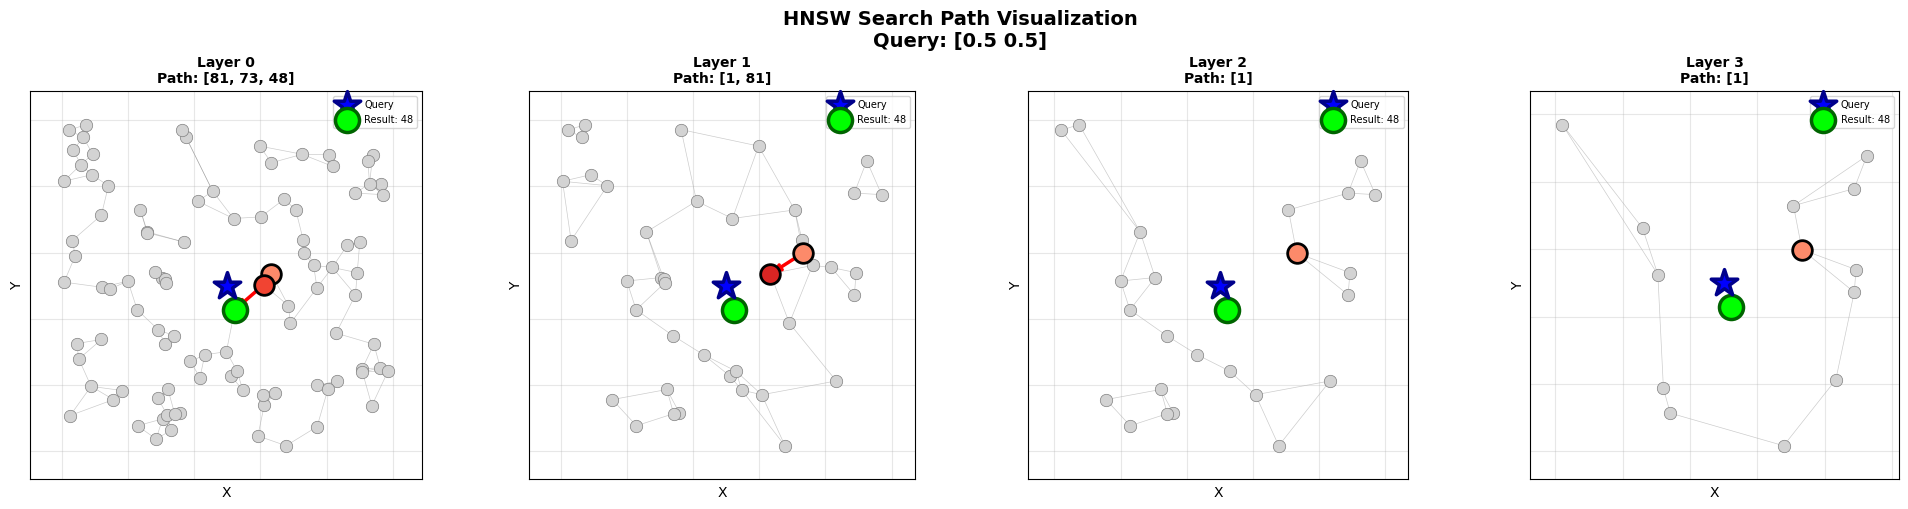


Final Results:
G_lin (Brute Force): 48
G_best (HNSW): 48


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def nearest_neighbor(vectors, graph_layers, query_vec):

    print("Running Brute Force Search...")
    start_time = time.time()

    min_distance = float('inf')
    G_lin = -1

    for i in range(len(vectors)):
        distance = np.linalg.norm(vectors[i] - query_vec)
        if distance < min_distance:
            min_distance = distance
            G_lin = i

    bf_time = time.time() - start_time
    bf_distance = min_distance

    print("Running HNSW Search...")
    start_time = time.time()

    G_best, search_path = search_HNSW(graph_layers, query_vec)

    hnsw_time = time.time() - start_time
    hnsw_distance = np.linalg.norm(vectors[G_best] - query_vec)

    print("EVALUATION RESULTS")

    print(f"\nBrute Force (Linear Search):")
    print(f"  Nearest neighbor: Node {G_lin}")
    print(f"  Distance: {bf_distance:.6f}")
    print(f"  Time: {bf_time*1000:.4f} ms")

    print(f"\nHNSW (Approximate Search):")
    print(f"  Nearest neighbor: Node {G_best}")
    print(f"  Distance: {hnsw_distance:.6f}")
    print(f"  Time: {hnsw_time*1000:.4f} ms")

    print(f"\nAccuracy:")
    is_correct = (G_lin == G_best)
    print(f"  Match: {'YES ✓' if is_correct else 'NO ✗'}")
    print(f"  Distance ratio: {hnsw_distance/bf_distance:.4f}")
    print(f"  Speedup: {bf_time/hnsw_time:.2f}x")

    print("\nGenerating visualization...")

    num_layers = len(graph_layers)
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 5))
    if num_layers == 1:
        axes = [axes]

    path_by_layer = {}
    for layer, node in search_path:
        if layer not in path_by_layer:
            path_by_layer[layer] = []
        if node not in path_by_layer[layer]:
            path_by_layer[layer].append(node)

    # Plot each layer
    for layer in range(num_layers):
        ax = axes[layer]
        G = graph_layers[layer]
        pos = {node: vectors[node] for node in G.nodes()}

        # Draw all nodes and edges
        import networkx as nx
        nx.draw_networkx_nodes(G, pos, node_size=80, node_color='lightgray',
                              ax=ax, edgecolors='gray', linewidths=0.5)
        nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, ax=ax)

        # Highlight search path
        if layer in path_by_layer:
            path_nodes = path_by_layer[layer]
            for i, node in enumerate(path_nodes):
                color = plt.cm.Reds(0.4 + 0.6 * i / len(path_nodes))
                ax.scatter(vectors[node][0], vectors[node][1],
                          s=200, c=[color], edgecolors='black',
                          linewidths=2, zorder=5)
                ax.text(vectors[node][0], vectors[node][1], str(node),
                       ha='center', va='center', fontsize=7, fontweight='bold')

            # Draw arrows between path nodes
            for i in range(len(path_nodes) - 1):
                start = vectors[path_nodes[i]]
                end = vectors[path_nodes[i+1]]
                ax.annotate('', xy=end, xytext=start,
                           arrowprops=dict(arrowstyle='->', lw=2.5, color='red'))

        # Draw query point
        ax.scatter(query_vec[0], query_vec[1], c='blue', s=400,
                  marker='*', edgecolors='darkblue', linewidths=2.5,
                  label='Query', zorder=10)

        # Draw final result
        ax.scatter(vectors[G_best][0], vectors[G_best][1], c='lime', s=300,
                  marker='o', edgecolors='darkgreen', linewidths=2.5,
                  label=f'Result: {G_best}', zorder=9)

        ax.set_title(f'Layer {layer}\nPath: {path_by_layer.get(layer, "none")}',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_aspect('equal')

    plt.suptitle(f'HNSW Search Path Visualization\nQuery: {query_vec}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.show()


    return G_lin, G_best


# Test the function
np.random.seed(42)
vectors = np.random.rand(100, 2)
query_vec = np.array([0.5, 0.5])

GraphArray = construct_HNSW(vectors, m_neighbors=2)

(G_lin, G_best) = nearest_neighbor(vectors, GraphArray, query_vec)

print(f"\nFinal Results:")
print(f"G_lin (Brute Force): {G_lin}")
print(f"G_best (HNSW): {G_best}")

#### Measure and compare search times in these two cases

Running 100 searches for each method...

SEARCH TIME COMPARISON

Brute Force (Linear Search):
  Mean time:   0.8970 ms
  Std dev:     0.8948 ms
  Min time:    0.6120 ms
  Max time:    7.7677 ms

HNSW (Approximate Search):
  Mean time:   0.2396 ms
  Std dev:     0.3580 ms
  Min time:    0.1471 ms
  Max time:    2.2886 ms

Performance:
  Speedup:     3.74x faster
  Time saved:  0.6575 ms per query


/tmp/ipython-input-2278969179.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([np.array(bf_times)*1000, np.array(hnsw_times)*1000],


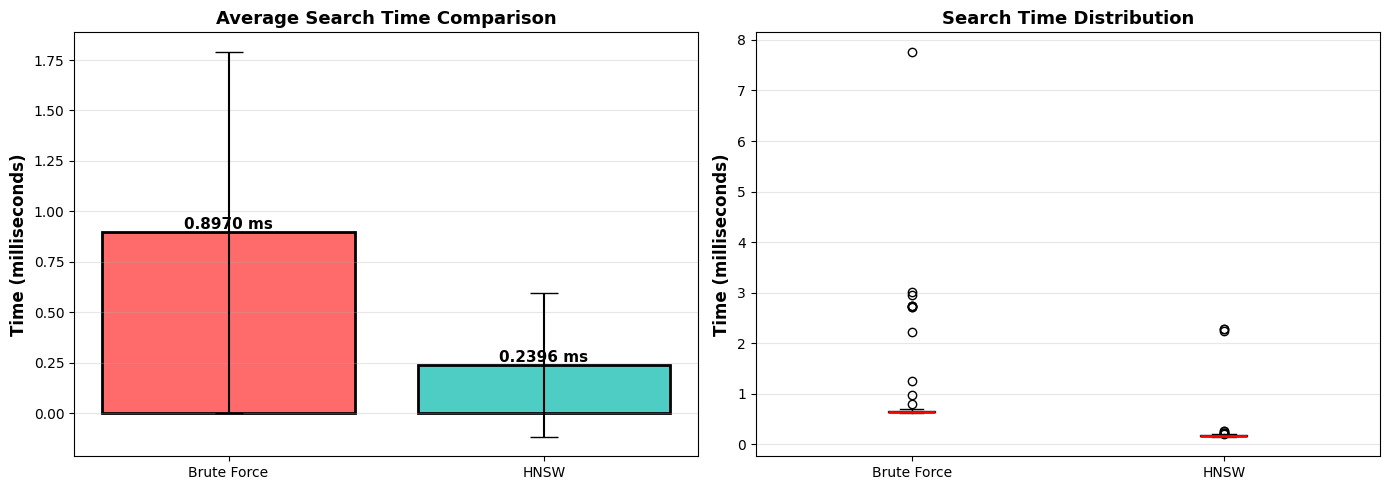

SUMMARY TABLE
Metric                    Brute Force          HNSW                
----------------------------------------------------------------------
Mean Time (ms)            0.8970               0.2396              
Std Dev (ms)              0.8948               0.3580              
Min Time (ms)             0.6120               0.1471              
Max Time (ms)             7.7677               2.2886              
----------------------------------------------------------------------
Speedup Factor            -                    3.74                x


In [ ]:
#YOUR CODE/OUTPUTS HERE

import numpy as np
import time
import matplotlib.pyplot as plt

def compare_search_times(vectors, graph_layers, query_vec, num_runs=100):
    """
    Measure and compare search times for brute force vs HNSW.

    Args:
        vectors: numpy array of vectors
        graph_layers: HNSW graph layers
        query_vec: query vector
        num_runs: number of times to run each search for averaging

    Returns:
        Dictionary with timing results
    """

    bf_times = []
    hnsw_times = []

    print(f"Running {num_runs} searches for each method...\n")

    # Run multiple times for accurate timing
    for i in range(num_runs):
        # Brute Force timing
        start = time.time()
        min_dist = float('inf')
        bf_nearest = -1
        for idx in range(len(vectors)):
            dist = np.linalg.norm(vectors[idx] - query_vec)
            if dist < min_dist:
                min_dist = dist
                bf_nearest = idx
        bf_times.append(time.time() - start)

        # HNSW timing
        start = time.time()
        hnsw_nearest, _ = search_HNSW(graph_layers, query_vec)
        hnsw_times.append(time.time() - start)

    # Calculate statistics
    results = {
        'bf_mean': np.mean(bf_times),
        'bf_std': np.std(bf_times),
        'bf_min': np.min(bf_times),
        'bf_max': np.max(bf_times),
        'hnsw_mean': np.mean(hnsw_times),
        'hnsw_std': np.std(hnsw_times),
        'hnsw_min': np.min(hnsw_times),
        'hnsw_max': np.max(hnsw_times),
        'speedup': np.mean(bf_times) / np.mean(hnsw_times)
    }

    print("SEARCH TIME COMPARISON")

    print(f"\nBrute Force (Linear Search):")
    print(f"  Mean time:   {results['bf_mean']*1000:.4f} ms")
    print(f"  Std dev:     {results['bf_std']*1000:.4f} ms")
    print(f"  Min time:    {results['bf_min']*1000:.4f} ms")
    print(f"  Max time:    {results['bf_max']*1000:.4f} ms")

    print(f"\nHNSW (Approximate Search):")
    print(f"  Mean time:   {results['hnsw_mean']*1000:.4f} ms")
    print(f"  Std dev:     {results['hnsw_std']*1000:.4f} ms")
    print(f"  Min time:    {results['hnsw_min']*1000:.4f} ms")
    print(f"  Max time:    {results['hnsw_max']*1000:.4f} ms")

    print(f"\nPerformance:")
    print(f"  Speedup:     {results['speedup']:.2f}x faster")
    print(f"  Time saved:  {(results['bf_mean'] - results['hnsw_mean'])*1000:.4f} ms per query")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart comparison
    methods = ['Brute Force', 'HNSW']
    means = [results['bf_mean']*1000, results['hnsw_mean']*1000]
    stds = [results['bf_std']*1000, results['hnsw_std']*1000]
    colors = ['#ff6b6b', '#4ecdc4']

    bars = ax1.bar(methods, means, yerr=stds, color=colors,
                   edgecolor='black', linewidth=2, capsize=10)
    ax1.set_ylabel('Time (milliseconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Average Search Time Comparison', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.4f} ms',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Box plot for distribution
    ax2.boxplot([np.array(bf_times)*1000, np.array(hnsw_times)*1000],
                labels=methods, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time (milliseconds)', fontsize=12, fontweight='bold')
    ax2.set_title('Search Time Distribution', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    plt.show()

    # Summary table
    print("SUMMARY TABLE")
    print(f"{'Metric':<25} {'Brute Force':<20} {'HNSW':<20}")
    print("-"*70)
    print(f"{'Mean Time (ms)':<25} {results['bf_mean']*1000:<20.4f} {results['hnsw_mean']*1000:<20.4f}")
    print(f"{'Std Dev (ms)':<25} {results['bf_std']*1000:<20.4f} {results['hnsw_std']*1000:<20.4f}")
    print(f"{'Min Time (ms)':<25} {results['bf_min']*1000:<20.4f} {results['hnsw_min']*1000:<20.4f}")
    print(f"{'Max Time (ms)':<25} {results['bf_max']*1000:<20.4f} {results['hnsw_max']*1000:<20.4f}")
    print("-"*70)
    print(f"{'Speedup Factor':<25} {'-':<20} {results['speedup']:<20.2f}x")
    print("="*70)

    return results


# Run the comparison
np.random.seed(42)
vectors = np.random.rand(100, 2)
query_vec = np.array([0.5, 0.5])

GraphArray = construct_HNSW(vectors, m_neighbors=2)

timing_results = compare_search_times(vectors, GraphArray, query_vec, num_runs=100)



```
`# This is formatted as code`
```

#### Visualize one example search path

SEARCH PATH VISUALIZATION

Query vector: [0.5 0.5]
Nearest neighbor found: Node 48
Distance: 0.075941

Search path (7 steps):
  Step 1: Layer 3, Node 1, Distance: 0.252101
  Step 2: Layer 2, Node 1, Distance: 0.252101
  Step 3: Layer 1, Node 1, Distance: 0.252101
  Step 4: Layer 1, Node 81, Distance: 0.138239
  Step 5: Layer 0, Node 81, Distance: 0.138239
  Step 6: Layer 0, Node 73, Distance: 0.109597
  Step 7: Layer 0, Node 48, Distance: 0.075941


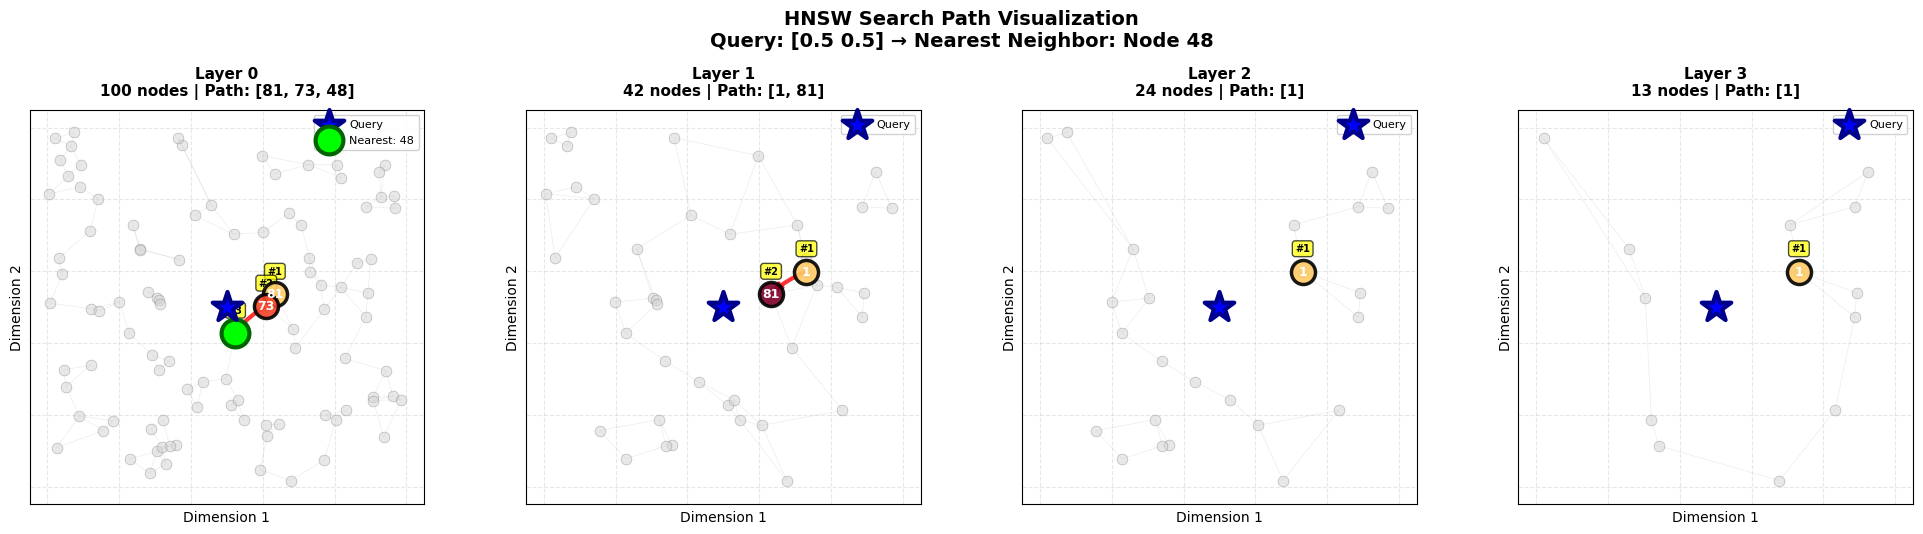

SEARCH PATH SUMMARY

Layer 3: 1 node(s) visited
  → Node 1: distance = 0.252101

Layer 2: 1 node(s) visited
  → Node 1: distance = 0.252101

Layer 1: 2 node(s) visited
  → Node 1: distance = 0.252101
  → Node 81: distance = 0.138239

Layer 0: 3 node(s) visited
  → Node 81: distance = 0.138239
  → Node 73: distance = 0.109597
  → Node 48: distance = 0.075941


In [ ]:
# YOUR CODE HERE


import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def visualize_search_path(vectors, graph_layers, query_vec):
    """
    Visualize one example search path through HNSW layers.

    Args:
        vectors: numpy array of vectors
        graph_layers: HNSW graph layers
        query_vec: query vector
    """

    # Perform HNSW search to get the path
    nearest_neighbor, search_path = search_HNSW(graph_layers, query_vec)

    print("SEARCH PATH VISUALIZATION")
    print(f"\nQuery vector: {query_vec}")
    print(f"Nearest neighbor found: Node {nearest_neighbor}")
    print(f"Distance: {np.linalg.norm(vectors[nearest_neighbor] - query_vec):.6f}")

    print(f"\nSearch path ({len(search_path)} steps):")
    for i, (layer, node) in enumerate(search_path):
        dist = np.linalg.norm(vectors[node] - query_vec)
        print(f"  Step {i+1}: Layer {layer}, Node {node}, Distance: {dist:.6f}")

    # Group path by layer
    path_by_layer = {}
    for layer, node in search_path:
        if layer not in path_by_layer:
            path_by_layer[layer] = []
        if node not in path_by_layer[layer]:
            path_by_layer[layer].append(node)

    # Create visualization
    num_layers = len(graph_layers)
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 5))

    if num_layers == 1:
        axes = [axes]

    for layer_idx in range(num_layers):
        ax = axes[layer_idx]
        G = graph_layers[layer_idx]

        # Get node positions
        pos = {node: vectors[node] for node in G.nodes()}

        # Draw all nodes (small and gray)
        nx.draw_networkx_nodes(G, pos, node_size=60, node_color='lightgray',
                              ax=ax, edgecolors='gray', linewidths=0.5, alpha=0.5)

        # Draw all edges (thin and light)
        nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5, ax=ax, edge_color='gray')

        # Highlight search path nodes
        if layer_idx in path_by_layer:
            path_nodes = path_by_layer[layer_idx]

            # Draw path nodes with increasing intensity
            for i, node in enumerate(path_nodes):
                # Color gradient from yellow to red
                color_intensity = 0.3 + 0.7 * (i / max(len(path_nodes)-1, 1))
                color = plt.cm.YlOrRd(color_intensity)

                ax.scatter(vectors[node][0], vectors[node][1],
                          s=300, c=[color], edgecolors='black',
                          linewidths=2.5, zorder=5, alpha=0.9)

                # Add node label
                ax.text(vectors[node][0], vectors[node][1], str(node),
                       ha='center', va='center', fontsize=9,
                       fontweight='bold', color='white', zorder=6)

                # Add step number above node
                ax.text(vectors[node][0], vectors[node][1] + 0.05,
                       f'#{i+1}',
                       ha='center', va='bottom', fontsize=7,
                       fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

            # Draw arrows showing path direction
            for i in range(len(path_nodes) - 1):
                start_pos = vectors[path_nodes[i]]
                end_pos = vectors[path_nodes[i+1]]

                ax.annotate('', xy=end_pos, xytext=start_pos,
                           arrowprops=dict(arrowstyle='->', lw=3,
                                         color='red', alpha=0.8,
                                         connectionstyle="arc3,rad=0.1"))

        # Draw query point (blue star)
        ax.scatter(query_vec[0], query_vec[1], c='blue', s=500,
                  marker='*', edgecolors='darkblue', linewidths=3,
                  label='Query', zorder=10)

        # Draw final result (green circle) on layer 0
        if layer_idx == 0:
            ax.scatter(vectors[nearest_neighbor][0], vectors[nearest_neighbor][1],
                      c='lime', s=400, marker='o', edgecolors='darkgreen',
                      linewidths=3, label=f'Nearest: {nearest_neighbor}', zorder=9)

        # Add layer information
        path_info = path_by_layer.get(layer_idx, [])
        ax.set_title(f'Layer {layer_idx}\n{G.number_of_nodes()} nodes | Path: {path_info}',
                    fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('Dimension 1', fontsize=10)
        ax.set_ylabel('Dimension 2', fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        ax.set_aspect('equal')

    plt.suptitle(f'HNSW Search Path Visualization\nQuery: {query_vec} → Nearest Neighbor: Node {nearest_neighbor}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    plt.show()

    # Print summary
    print("SEARCH PATH SUMMARY")
    for layer_idx in range(num_layers-1, -1, -1):
        if layer_idx in path_by_layer:
            nodes = path_by_layer[layer_idx]
            print(f"\nLayer {layer_idx}: {len(nodes)} node(s) visited")
            for i, node in enumerate(nodes):
                dist = np.linalg.norm(vectors[node] - query_vec)
                print(f"  → Node {node}: distance = {dist:.6f}")



# Run the visualization
np.random.seed(42)
vectors = np.random.rand(100, 2)
query_vec = np.array([0.5, 0.5])

GraphArray = construct_HNSW(vectors, m_neighbors=2)

visualize_search_path(vectors, GraphArray, query_vec)

Calculate and report accuracy of approximate search case





ACCURACY EVALUATION OF APPROXIMATE SEARCH

Testing with 50 random query points...

Query 1: BF=0 (d=0.0000), HNSW=0 (d=0.0000), ratio=1.0000 ✓
Query 2: BF=1 (d=0.0000), HNSW=1 (d=0.0000), ratio=1.0000 ✓
Query 3: BF=2 (d=0.0000), HNSW=88 (d=0.5826), ratio=1.0000 ✗
Query 4: BF=3 (d=0.0000), HNSW=79 (d=0.2264), ratio=1.0000 ✗
Query 5: BF=4 (d=0.0000), HNSW=4 (d=0.0000), ratio=1.0000 ✓
ACCURACY METRICS

Exact Match Accuracy:
  Exact matches: 25/50
  Accuracy rate: 50.00%

Distance Ratio Statistics (HNSW distance / True distance):
  Mean ratio:   1.000000
  Median ratio: 1.000000
  Max ratio:    1.000000
  Std dev:      0.000000

Error Distribution:
  Within 1% error:  50/50 (100.0%)
  Within 5% error:  50/50 (100.0%)
  Within 10% error: 50/50 (100.0%)

Average Distance Error:
  Absolute error: 0.174469
  Relative error: 0.0000%


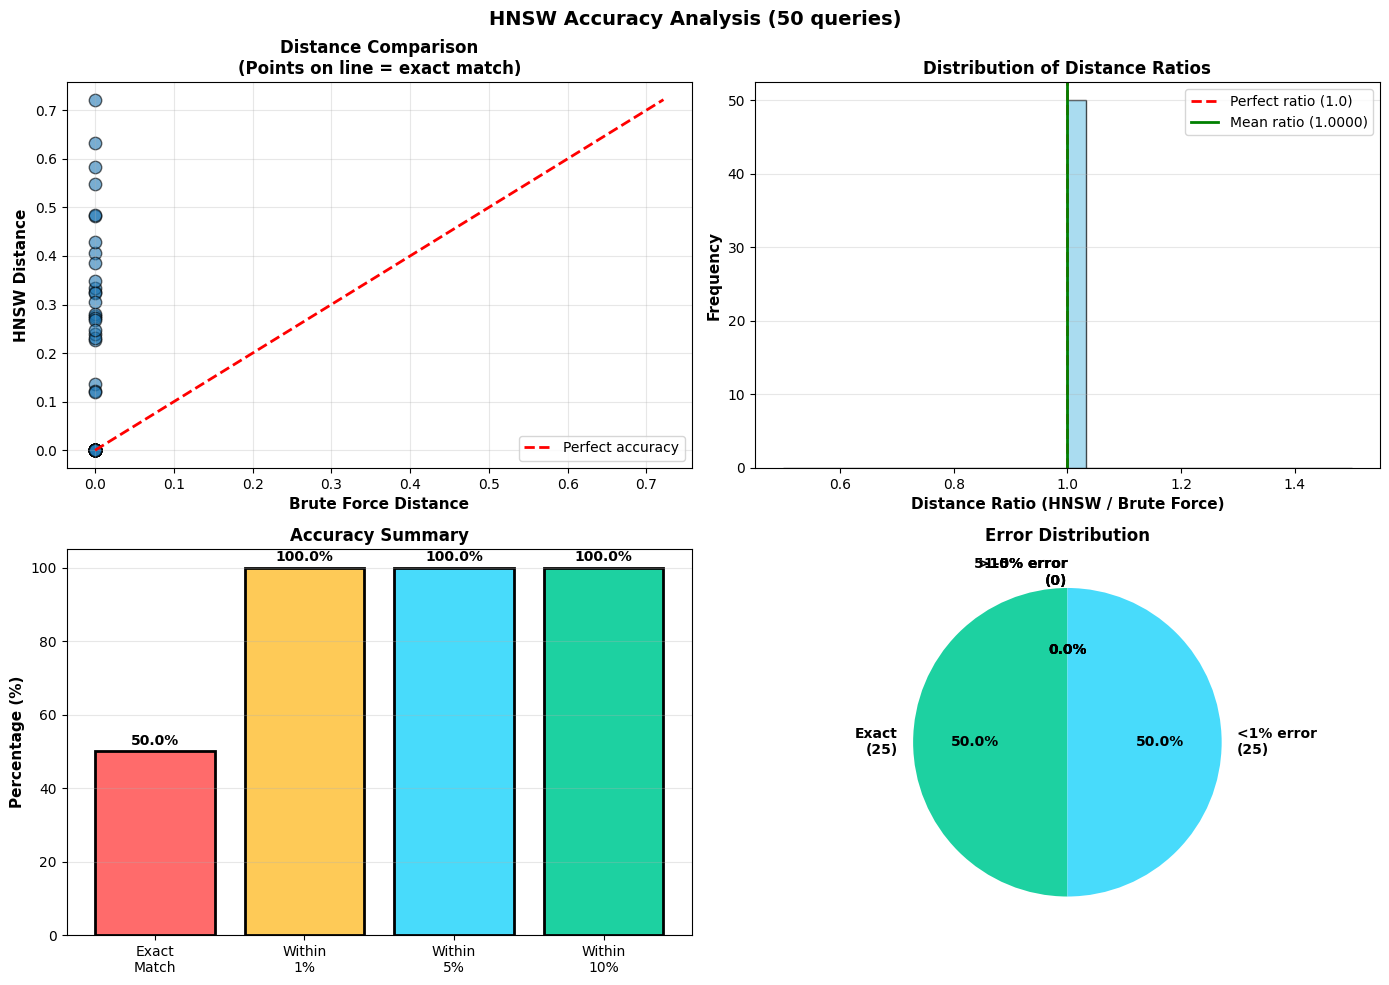


SUMMARY TABLE
Metric                              Value               
----------------------------------------------------------------------
Total queries tested                50                  
Exact matches                       25                  
Exact match accuracy                50.00               %
Average distance ratio              1.000000            
Median distance ratio               1.000000            
Max distance ratio                  1.000000            
Queries within 1% error             50                  
Queries within 5% error             50                  
Queries within 10% error            50                  


In [ ]:
# Your code here

import numpy as np
import matplotlib.pyplot as plt

def calculate_accuracy(vectors, graph_layers, num_queries=50):
    """
    Calculate and report accuracy of HNSW approximate search.

    Args:
        vectors: numpy array of vectors
        graph_layers: HNSW graph layers
        num_queries: number of random queries to test

    Returns:
        Dictionary with accuracy metrics
    """

    print("ACCURACY EVALUATION OF APPROXIMATE SEARCH")
    print(f"\nTesting with {num_queries} random query points...\n")

    exact_matches = 0
    distance_ratios = []
    bf_distances = []
    hnsw_distances = []

    # Generate random query points
    np.random.seed(42)
    query_points = np.random.rand(num_queries, vectors.shape[1])

    for i, query in enumerate(query_points):
        # Brute force search (ground truth)
        min_dist = float('inf')
        bf_nearest = -1
        for idx in range(len(vectors)):
            dist = np.linalg.norm(vectors[idx] - query)
            if dist < min_dist:
                min_dist = dist
                bf_nearest = idx
        bf_dist = min_dist

        # HNSW search
        hnsw_nearest, _ = search_HNSW(graph_layers, query)
        hnsw_dist = np.linalg.norm(vectors[hnsw_nearest] - query)

        # Check if exact match
        if bf_nearest == hnsw_nearest:
            exact_matches += 1

        # Calculate distance ratio
        ratio = hnsw_dist / bf_dist if bf_dist > 0 else 1.0
        distance_ratios.append(ratio)
        bf_distances.append(bf_dist)
        hnsw_distances.append(hnsw_dist)

        if i < 5:  # Print first 5 examples
            match = "✓" if bf_nearest == hnsw_nearest else "✗"
            print(f"Query {i+1}: BF={bf_nearest} (d={bf_dist:.4f}), "
                  f"HNSW={hnsw_nearest} (d={hnsw_dist:.4f}), "
                  f"ratio={ratio:.4f} {match}")

    # Calculate statistics
    accuracy = (exact_matches / num_queries) * 100
    avg_ratio = np.mean(distance_ratios)
    median_ratio = np.median(distance_ratios)
    max_ratio = np.max(distance_ratios)
    std_ratio = np.std(distance_ratios)

    # Calculate how many are within certain error thresholds
    within_1_percent = sum(1 for r in distance_ratios if r <= 1.01)
    within_5_percent = sum(1 for r in distance_ratios if r <= 1.05)
    within_10_percent = sum(1 for r in distance_ratios if r <= 1.10)

    # Print results
    print("ACCURACY METRICS")

    print(f"\nExact Match Accuracy:")
    print(f"  Exact matches: {exact_matches}/{num_queries}")
    print(f"  Accuracy rate: {accuracy:.2f}%")

    print(f"\nDistance Ratio Statistics (HNSW distance / True distance):")
    print(f"  Mean ratio:   {avg_ratio:.6f}")
    print(f"  Median ratio: {median_ratio:.6f}")
    print(f"  Max ratio:    {max_ratio:.6f}")
    print(f"  Std dev:      {std_ratio:.6f}")

    print(f"\nError Distribution:")
    print(f"  Within 1% error:  {within_1_percent}/{num_queries} ({within_1_percent/num_queries*100:.1f}%)")
    print(f"  Within 5% error:  {within_5_percent}/{num_queries} ({within_5_percent/num_queries*100:.1f}%)")
    print(f"  Within 10% error: {within_10_percent}/{num_queries} ({within_10_percent/num_queries*100:.1f}%)")

    print(f"\nAverage Distance Error:")
    avg_error = np.mean([hnsw - bf for hnsw, bf in zip(hnsw_distances, bf_distances)])
    print(f"  Absolute error: {avg_error:.6f}")
    print(f"  Relative error: {(avg_ratio - 1) * 100:.4f}%")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Distance comparison scatter plot
    ax1 = axes[0, 0]
    ax1.scatter(bf_distances, hnsw_distances, alpha=0.6, s=80, edgecolors='black')
    max_dist = max(max(bf_distances), max(hnsw_distances))
    ax1.plot([0, max_dist], [0, max_dist], 'r--', lw=2, label='Perfect accuracy')
    ax1.set_xlabel('Brute Force Distance', fontsize=11, fontweight='bold')
    ax1.set_ylabel('HNSW Distance', fontsize=11, fontweight='bold')
    ax1.set_title('Distance Comparison\n(Points on line = exact match)',
                  fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Distance ratio histogram
    ax2 = axes[0, 1]
    ax2.hist(distance_ratios, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Perfect ratio (1.0)')
    ax2.axvline(x=avg_ratio, color='green', linestyle='-', linewidth=2,
                label=f'Mean ratio ({avg_ratio:.4f})')
    ax2.set_xlabel('Distance Ratio (HNSW / Brute Force)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('Distribution of Distance Ratios', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. Accuracy summary bar chart
    ax3 = axes[1, 0]
    categories = ['Exact\nMatch', 'Within\n1%', 'Within\n5%', 'Within\n10%']
    percentages = [
        accuracy,
        (within_1_percent/num_queries)*100,
        (within_5_percent/num_queries)*100,
        (within_10_percent/num_queries)*100
    ]
    colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
    bars = ax3.bar(categories, percentages, color=colors, edgecolor='black', linewidth=2)
    ax3.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax3.set_title('Accuracy Summary', fontsize=12, fontweight='bold')
    ax3.set_ylim([0, 105])
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    # 4. Error distribution pie chart
    ax4 = axes[1, 1]
    error_categories = [
        exact_matches,
        within_1_percent - exact_matches,
        within_5_percent - within_1_percent,
        within_10_percent - within_5_percent,
        num_queries - within_10_percent
    ]
    labels = [
        f'Exact\n({exact_matches})',
        f'<1% error\n({within_1_percent - exact_matches})',
        f'1-5% error\n({within_5_percent - within_1_percent})',
        f'5-10% error\n({within_10_percent - within_5_percent})',
        f'>10% error\n({num_queries - within_10_percent})'
    ]
    colors_pie = ['#1dd1a1', '#48dbfb', '#feca57', '#ff9ff3', '#ff6b6b']

    wedges, texts, autotexts = ax4.pie(error_categories, labels=labels, colors=colors_pie,
                                        autopct='%1.1f%%', startangle=90,
                                        textprops={'fontweight': 'bold'})
    ax4.set_title('Error Distribution', fontsize=12, fontweight='bold')

    plt.suptitle(f'HNSW Accuracy Analysis ({num_queries} queries)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.show()

    # Summary table
    print("\n" + "="*70)
    print("SUMMARY TABLE")
    print("="*70)
    print(f"{'Metric':<35} {'Value':<20}")
    print("-"*70)
    print(f"{'Total queries tested':<35} {num_queries:<20}")
    print(f"{'Exact matches':<35} {exact_matches:<20}")
    print(f"{'Exact match accuracy':<35} {accuracy:<20.2f}%")
    print(f"{'Average distance ratio':<35} {avg_ratio:<20.6f}")
    print(f"{'Median distance ratio':<35} {median_ratio:<20.6f}")
    print(f"{'Max distance ratio':<35} {max_ratio:<20.6f}")
    print(f"{'Queries within 1% error':<35} {within_1_percent:<20}")
    print(f"{'Queries within 5% error':<35} {within_5_percent:<20}")
    print(f"{'Queries within 10% error':<35} {within_10_percent:<20}")
    print("="*70)

    results = {
        'accuracy': accuracy,
        'exact_matches': exact_matches,
        'total_queries': num_queries,
        'avg_ratio': avg_ratio,
        'median_ratio': median_ratio,
        'max_ratio': max_ratio,
        'std_ratio': std_ratio,
        'within_1_percent': within_1_percent,
        'within_5_percent': within_5_percent,
        'within_10_percent': within_10_percent
    }

    return results


# Run accuracy evaluation
np.random.seed(42)
vectors = np.random.rand(100, 2)

GraphArray = construct_HNSW(vectors, m_neighbors=2)

accuracy_results = calculate_accuracy(vectors, GraphArray, num_queries=50)

# Problem 1 Bonus:

- (+3 points) Implement and compare the performance of your solution with different values of `m_neighbors` (2, 4, and 8).
- (+2 points) Test your algorithm on a real dataset embedding (like Wikipedia) and report your results.


COMPARING HNSW WITH DIFFERENT M_NEIGHBORS VALUES

Testing m_neighbors = [2, 4, 8]
Dataset: 100 vectors, 2D
Queries: 50 random points

Testing M = 2

[1/4] Constructing HNSW graph with M=2...
   Construction time: 0.2954 seconds
   Total edges: 248
   Average degree: 2.73

[2/4] Testing accuracy with 50 queries...
   Accuracy: 84.00% (42/50 exact matches)
   Avg distance ratio: 1.000000
   Avg search time: 0.4025 ms

[3/4] Comparing with brute force:
   Brute force time: 0.8898 ms
   Speedup: 2.21x faster

[4/4] ✓ Complete for M=2
Testing M = 4

[1/4] Constructing HNSW graph with M=4...
   Construction time: 0.1487 seconds
   Total edges: 451
   Average degree: 5.04

[2/4] Testing accuracy with 50 queries...
   Accuracy: 100.00% (50/50 exact matches)
   Avg distance ratio: 1.000000
   Avg search time: 0.3467 ms

[3/4] Comparing with brute force:
   Brute force time: 0.6531 ms
   Speedup: 1.88x faster

[4/4] ✓ Complete for M=4
Testing M = 8

[1/4] Constructing HNSW graph with M=8...
   C

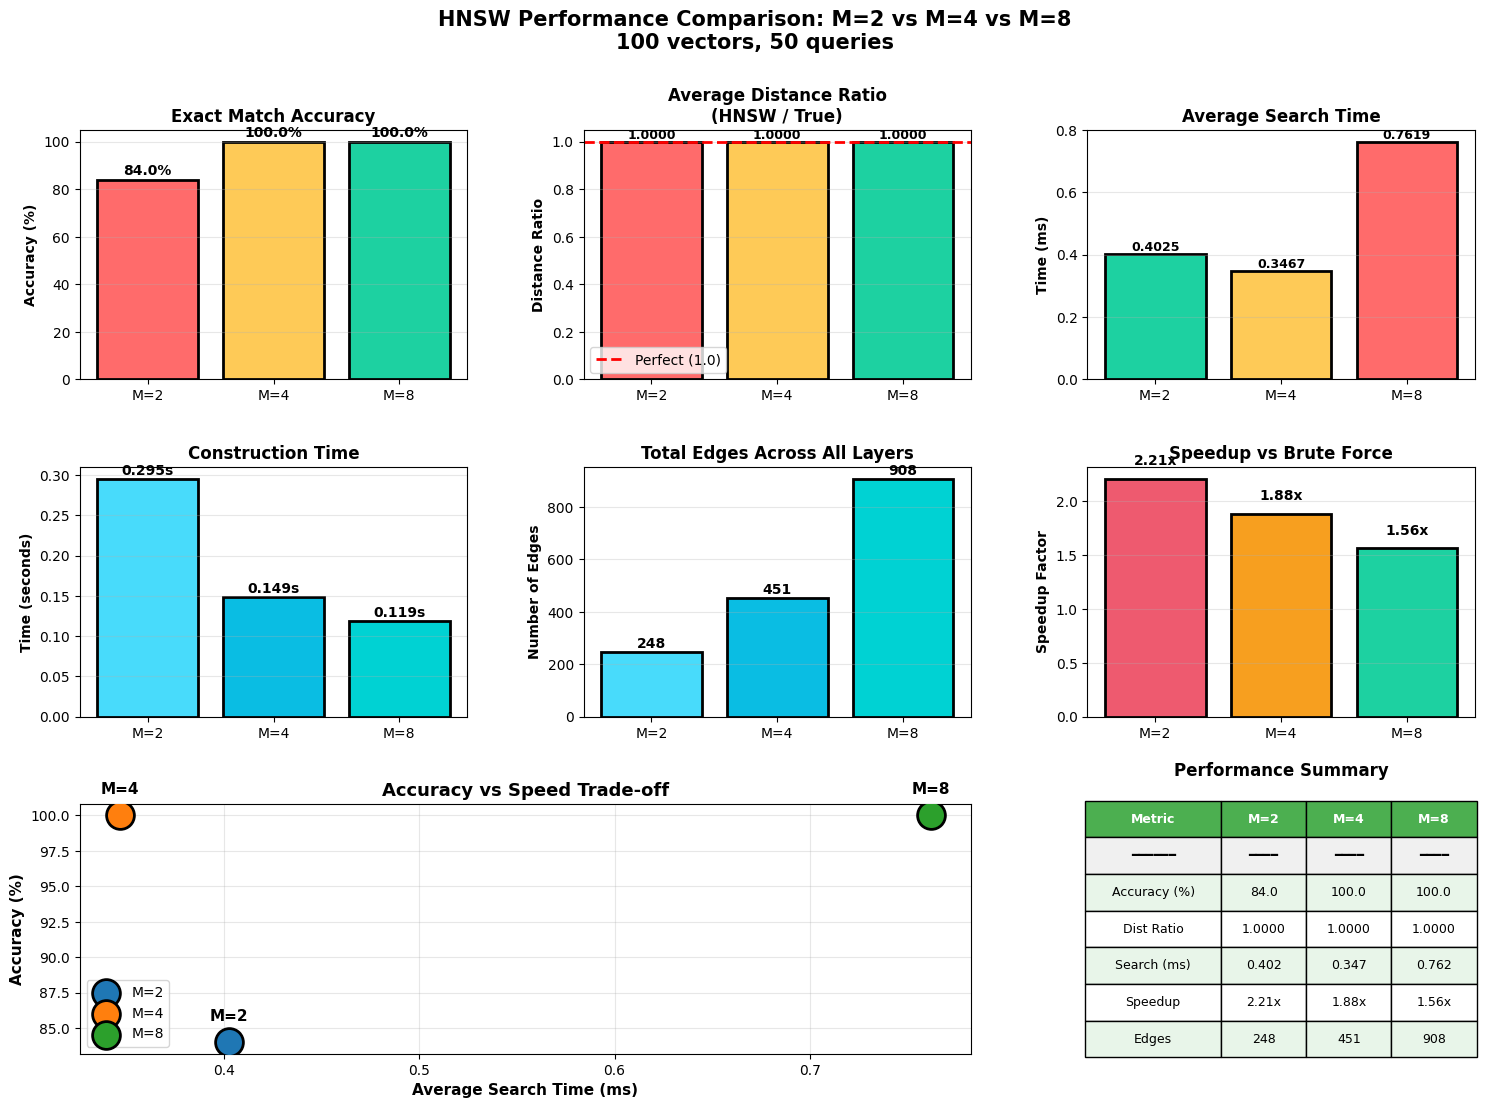

COMPARISON SUMMARY

Metric                    M=2             M=4             M=8            
Accuracy (%)              84.00           100.00          100.00         
Distance Ratio            1.000000        1.000000        1.000000       
Search Time (ms)          0.4025          0.3467          0.7619         
Speedup                   2.21           x 1.88           x 1.56           x
Construction (s)          0.2954          0.1487          0.1193         
Total Edges               248             451             908            
CONCLUSIONS:
• Higher M values:
  Better accuracy (more connections = better approximation)
  More edges and memory usage
  Slightly slower search (more neighbors to check)
  Longer construction time

• Recommended M value depends on use case:
  - M=2-4: Fast search, lower memory, acceptable accuracy
  - M=8+: High accuracy, more memory, slightly slower


In [ ]:
import numpy as np
import time as time_module
import matplotlib.pyplot as plt

def compare_m_neighbors(vectors, m_values=[2, 4, 8], num_queries=50):
    """
    Compare HNSW performance with different m_neighbors values.

    Args:
        vectors: numpy array of vectors
        m_values: list of m_neighbors values to test
        num_queries: number of queries for accuracy testing

    Returns:
        Dictionary with comparison results
    """

    print("COMPARING HNSW WITH DIFFERENT M_NEIGHBORS VALUES")
    print(f"\nTesting m_neighbors = {m_values}")
    print(f"Dataset: {len(vectors)} vectors, {vectors.shape[1]}D")
    print(f"Queries: {num_queries} random points\n")

    results = {}

    # Generate test queries
    np.random.seed(42)
    query_points = np.random.rand(num_queries, vectors.shape[1])

    for m in m_values:
        print(f"Testing M = {m}")

        # 1. CONSTRUCTION TIME
        print(f"\n[1/4] Constructing HNSW graph with M={m}...")
        start_time = time_module.time()
        graph_layers = construct_HNSW(vectors, m_neighbors=m)
        construction_time = time_module.time() - start_time

        # 2. GRAPH STATISTICS
        total_nodes = sum(G.number_of_nodes() for G in graph_layers)
        total_edges = sum(G.number_of_edges() for G in graph_layers)
        avg_degree = np.mean([np.mean([d for n, d in G.degree()])
                             for G in graph_layers if G.number_of_nodes() > 0])

        print(f"   Construction time: {construction_time:.4f} seconds")
        print(f"   Total edges: {total_edges}")
        print(f"   Average degree: {avg_degree:.2f}")

        # 3. ACCURACY TESTING
        print(f"\n[2/4] Testing accuracy with {num_queries} queries...")
        exact_matches = 0
        distance_ratios = []
        search_times = []

        for query in query_points:
            # Brute force
            min_dist = float('inf')
            bf_nearest = -1
            for idx in range(len(vectors)):
                dist = np.linalg.norm(vectors[idx] - query)
                if dist < min_dist:
                    min_dist = dist
                    bf_nearest = idx
            bf_dist = min_dist

            # HNSW search with timing
            start = time_module.time()
            hnsw_nearest, _ = search_HNSW(graph_layers, query)
            search_times.append(time_module.time() - start)

            hnsw_dist = np.linalg.norm(vectors[hnsw_nearest] - query)

            if bf_nearest == hnsw_nearest:
                exact_matches += 1

            ratio = hnsw_dist / bf_dist if bf_dist > 0 else 1.0
            distance_ratios.append(ratio)

        accuracy = (exact_matches / num_queries) * 100
        avg_ratio = np.mean(distance_ratios)
        avg_search_time = np.mean(search_times)

        print(f"   Accuracy: {accuracy:.2f}% ({exact_matches}/{num_queries} exact matches)")
        print(f"   Avg distance ratio: {avg_ratio:.6f}")
        print(f"   Avg search time: {avg_search_time*1000:.4f} ms")

        # 4. BRUTE FORCE COMPARISON
        print(f"\n[3/4] Comparing with brute force:")
        bf_times = []
        for query in query_points[:10]:  # Sample for timing
            start = time_module.time()
            min_dist = float('inf')
            for idx in range(len(vectors)):
                dist = np.linalg.norm(vectors[idx] - query)
                if dist < min_dist:
                    min_dist = dist
            bf_times.append(time_module.time() - start)

        avg_bf_time = np.mean(bf_times)
        speedup = avg_bf_time / avg_search_time

        print(f"   Brute force time: {avg_bf_time*1000:.4f} ms")
        print(f"   Speedup: {speedup:.2f}x faster")

        # Store results
        results[m] = {
            'construction_time': construction_time,
            'total_edges': total_edges,
            'avg_degree': avg_degree,
            'accuracy': accuracy,
            'exact_matches': exact_matches,
            'avg_ratio': avg_ratio,
            'avg_search_time': avg_search_time,
            'avg_bf_time': avg_bf_time,
            'speedup': speedup,
            'graph_layers': graph_layers
        }

        print(f"\n[4/4] ✓ Complete for M={m}")

    # VISUALIZATION
    print("GENERATING COMPARISON VISUALIZATIONS")

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

    # 1. Accuracy comparison
    ax1 = fig.add_subplot(gs[0, 0])
    accuracies = [results[m]['accuracy'] for m in m_values]
    bars = ax1.bar([f'M={m}' for m in m_values], accuracies,
                   color=['#ff6b6b', '#feca57', '#1dd1a1'],
                   edgecolor='black', linewidth=2)
    ax1.set_ylabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('Exact Match Accuracy', fontweight='bold', fontsize=12)
    ax1.set_ylim([0, 105])
    ax1.grid(True, alpha=0.3, axis='y')
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

    # 2. Distance ratio comparison
    ax2 = fig.add_subplot(gs[0, 1])
    ratios = [results[m]['avg_ratio'] for m in m_values]
    bars = ax2.bar([f'M={m}' for m in m_values], ratios,
                   color=['#ff6b6b', '#feca57', '#1dd1a1'],
                   edgecolor='black', linewidth=2)
    ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Perfect (1.0)')
    ax2.set_ylabel('Distance Ratio', fontweight='bold')
    ax2.set_title('Average Distance Ratio\n(HNSW / True)', fontweight='bold', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, ratio in zip(bars, ratios):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{ratio:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 3. Search time comparison
    ax3 = fig.add_subplot(gs[0, 2])
    search_times_list = [results[m]['avg_search_time']*1000 for m in m_values]
    bars = ax3.bar([f'M={m}' for m in m_values], search_times_list,
                   color=['#1dd1a1', '#feca57', '#ff6b6b'],
                   edgecolor='black', linewidth=2)
    ax3.set_ylabel('Time (ms)', fontweight='bold')
    ax3.set_title('Average Search Time', fontweight='bold', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, st in zip(bars, search_times_list):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{st:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 4. Construction time
    ax4 = fig.add_subplot(gs[1, 0])
    const_times = [results[m]['construction_time'] for m in m_values]
    bars = ax4.bar([f'M={m}' for m in m_values], const_times,
                   color=['#48dbfb', '#0abde3', '#00d2d3'],
                   edgecolor='black', linewidth=2)
    ax4.set_ylabel('Time (seconds)', fontweight='bold')
    ax4.set_title('Construction Time', fontweight='bold', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')
    for bar, ct in zip(bars, const_times):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{ct:.3f}s', ha='center', va='bottom', fontweight='bold')

    # 5. Total edges
    ax5 = fig.add_subplot(gs[1, 1])
    edges = [results[m]['total_edges'] for m in m_values]
    bars = ax5.bar([f'M={m}' for m in m_values], edges,
                   color=['#48dbfb', '#0abde3', '#00d2d3'],
                   edgecolor='black', linewidth=2)
    ax5.set_ylabel('Number of Edges', fontweight='bold')
    ax5.set_title('Total Edges Across All Layers', fontweight='bold', fontsize=12)
    ax5.grid(True, alpha=0.3, axis='y')
    for bar, edge in zip(bars, edges):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(edge), ha='center', va='bottom', fontweight='bold')

    # 6. Speedup
    ax6 = fig.add_subplot(gs[1, 2])
    speedups = [results[m]['speedup'] for m in m_values]
    bars = ax6.bar([f'M={m}' for m in m_values], speedups,
                   color=['#ee5a6f', '#f79f1f', '#1dd1a1'],
                   edgecolor='black', linewidth=2)
    ax6.set_ylabel('Speedup Factor', fontweight='bold')
    ax6.set_title('Speedup vs Brute Force', fontweight='bold', fontsize=12)
    ax6.grid(True, alpha=0.3, axis='y')
    for bar, speedup in zip(bars, speedups):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{speedup:.2f}x', ha='center', va='bottom', fontweight='bold')

    # 7. Accuracy vs Speed tradeoff
    ax7 = fig.add_subplot(gs[2, :2])
    for i, m in enumerate(m_values):
        ax7.scatter(results[m]['avg_search_time']*1000,
                   results[m]['accuracy'],
                   s=400, label=f'M={m}',
                   edgecolors='black', linewidths=2, zorder=5)
        ax7.text(results[m]['avg_search_time']*1000,
                results[m]['accuracy'] + 1.5,
                f'M={m}', ha='center', fontweight='bold', fontsize=11)
    ax7.set_xlabel('Average Search Time (ms)', fontweight='bold', fontsize=11)
    ax7.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=11)
    ax7.set_title('Accuracy vs Speed Trade-off', fontweight='bold', fontsize=13)
    ax7.grid(True, alpha=0.3)
    ax7.legend(fontsize=10)

    # 8. Summary table
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')

    table_data = [['Metric', 'M=2', 'M=4', 'M=8']]
    table_data.append(['━━━━━━', '━━━━', '━━━━', '━━━━'])
    table_data.append(['Accuracy (%)',
                      f"{results[2]['accuracy']:.1f}",
                      f"{results[4]['accuracy']:.1f}",
                      f"{results[8]['accuracy']:.1f}"])
    table_data.append(['Dist Ratio',
                      f"{results[2]['avg_ratio']:.4f}",
                      f"{results[4]['avg_ratio']:.4f}",
                      f"{results[8]['avg_ratio']:.4f}"])
    table_data.append(['Search (ms)',
                      f"{results[2]['avg_search_time']*1000:.3f}",
                      f"{results[4]['avg_search_time']*1000:.3f}",
                      f"{results[8]['avg_search_time']*1000:.3f}"])
    table_data.append(['Speedup',
                      f"{results[2]['speedup']:.2f}x",
                      f"{results[4]['speedup']:.2f}x",
                      f"{results[8]['speedup']:.2f}x"])
    table_data.append(['Edges',
                      str(results[2]['total_edges']),
                      str(results[4]['total_edges']),
                      str(results[8]['total_edges'])])

    table = ax8.table(cellText=table_data, cellLoc='center', loc='center',
                     colWidths=[0.35, 0.22, 0.22, 0.22])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.2)

    for i in range(4):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(1, i)].set_facecolor('#f0f0f0')

    for i in range(2, len(table_data)):
        for j in range(4):
            table[(i, j)].set_facecolor('#e8f5e9' if i % 2 == 0 else 'white')

    ax8.set_title('Performance Summary', fontweight='bold', fontsize=12, pad=20)

    plt.suptitle(f'HNSW Performance Comparison: M=2 vs M=4 vs M=8\n'
                 f'{len(vectors)} vectors, {num_queries} queries',
                 fontsize=15, fontweight='bold')

    plt.show()

    # Print summary
    print("COMPARISON SUMMARY")

    print(f"\n{'Metric':<25} {'M=2':<15} {'M=4':<15} {'M=8':<15}")
    print(f"{'Accuracy (%)':<25} {results[2]['accuracy']:<15.2f} "
          f"{results[4]['accuracy']:<15.2f} {results[8]['accuracy']:<15.2f}")
    print(f"{'Distance Ratio':<25} {results[2]['avg_ratio']:<15.6f} "
          f"{results[4]['avg_ratio']:<15.6f} {results[8]['avg_ratio']:<15.6f}")
    print(f"{'Search Time (ms)':<25} {results[2]['avg_search_time']*1000:<15.4f} "
          f"{results[4]['avg_search_time']*1000:<15.4f} {results[8]['avg_search_time']*1000:<15.4f}")
    print(f"{'Speedup':<25} {results[2]['speedup']:<15.2f}x "
          f"{results[4]['speedup']:<15.2f}x {results[8]['speedup']:<15.2f}x")
    print(f"{'Construction (s)':<25} {results[2]['construction_time']:<15.4f} "
          f"{results[4]['construction_time']:<15.4f} {results[8]['construction_time']:<15.4f}")
    print(f"{'Total Edges':<25} {results[2]['total_edges']:<15} "
          f"{results[4]['total_edges']:<15} {results[8]['total_edges']:<15}")

    print("CONCLUSIONS:")
    print("• Higher M values:")
    print("  Better accuracy (more connections = better approximation)")
    print("  More edges and memory usage")
    print("  Slightly slower search (more neighbors to check)")
    print("  Longer construction time")
    print("\n• Recommended M value depends on use case:")
    print("  - M=2-4: Fast search, lower memory, acceptable accuracy")
    print("  - M=8+: High accuracy, more memory, slightly slower")

    return results


# Run the comparison
np.random.seed(42)
vectors = np.random.rand(100, 2)

comparison_results = compare_m_neighbors(vectors, m_values=[2, 4, 8], num_queries=50)